# IR ALEM 2 - Inteligencia Artificial em series temporais de saude

Este notebook compara uma abordagem tradicional, baseada em regressao logistica, com uma abordagem neuromorfica simples usando neuronios LIF (*Leaky Integrate-and-Fire*).

O sinal vital usado e uma serie temporal sintetica de batimentos cardiacos, representando tres classes: normal, taquicardia e irregular.

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Geracao da base sintetica

Em um projeto real, esta etapa seria substituida por uma base clinica validada. Aqui a simulacao permite manter o notebook reprodutivel e focar na comparacao dos modelos.

In [3]:
def simulate_heart_rate_dataset(n_samples=900, window_size=180, seed=42):
    """Gera janelas sinteticas de batimentos cardiacos em bpm."""
    rng = np.random.default_rng(seed)
    classes = np.array(['normal', 'taquicardia', 'irregular'])
    signals = []
    labels = []
    t = np.linspace(0, 1, window_size)

    for i in range(n_samples):
        label = classes[i % len(classes)]

        if label == 'normal':
            baseline = rng.normal(72, 4)
            amplitude = rng.uniform(2, 5)
            noise = rng.normal(0, 1.8, window_size)
            signal = baseline + amplitude * np.sin(2 * np.pi * rng.uniform(2, 4) * t) + noise
        elif label == 'taquicardia':
            baseline = rng.normal(118, 7)
            trend = rng.normal(8, 3) * t
            noise = rng.normal(0, 2.4, window_size)
            signal = baseline + trend + 3 * np.sin(2 * np.pi * rng.uniform(3, 6) * t) + noise
        else:
            baseline = rng.normal(83, 6)
            noise = rng.normal(0, 4.2, window_size)
            jumps = rng.choice([0, 1], size=window_size, p=[0.91, 0.09]) * rng.normal(0, 18, window_size)
            signal = baseline + 4 * np.sin(2 * np.pi * rng.uniform(1, 5) * t) + noise + jumps

        signals.append(np.clip(signal, 45, 170))
        labels.append(label)

    return np.array(signals), np.array(labels)

X_raw, y = simulate_heart_rate_dataset()
print(X_raw.shape, y.shape)
pd.Series(y).value_counts()

(900, 180) (900,)


normal         300
taquicardia    300
irregular      300
Name: count, dtype: int64

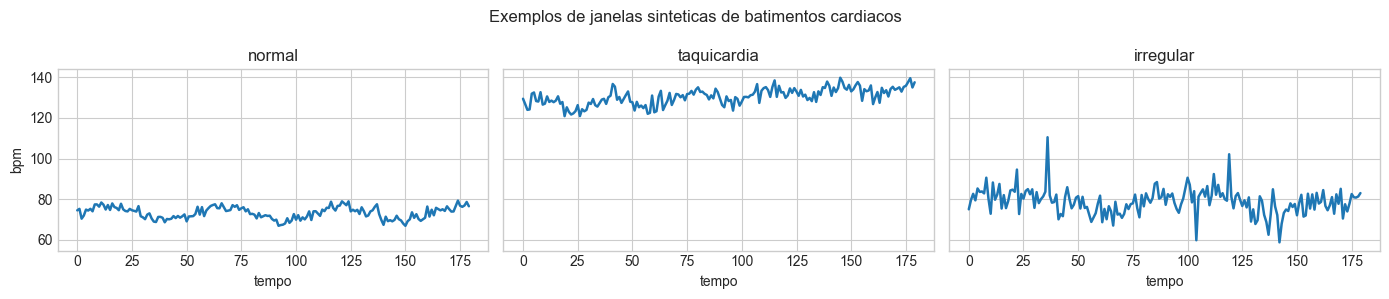

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, label in zip(axes, ['normal', 'taquicardia', 'irregular']):
    idx = np.where(y == label)[0][0]
    ax.plot(X_raw[idx], linewidth=1.8)
    ax.set_title(label)
    ax.set_xlabel('tempo')
axes[0].set_ylabel('bpm')
plt.suptitle('Exemplos de janelas sinteticas de batimentos cardiacos')
plt.tight_layout()
plt.show()

## 2. Modelo tradicional: atributos + regressao logistica

A regressao logistica recebe atributos resumidos da janela temporal. A ideia e criar uma linha de base interpretavel e facil de reproduzir.

In [5]:
def extract_statistical_features(signals):
    """Extrai atributos estatisticos e temporais simples de cada janela."""
    rows = []
    for x in signals:
        diff = np.diff(x)
        centered = x - x.mean()
        spectrum = np.abs(np.fft.rfft(centered)) ** 2
        low_energy = spectrum[1:6].sum()
        high_energy = spectrum[6:20].sum()
        autocorr_1 = np.corrcoef(x[:-1], x[1:])[0, 1]

        rows.append({
            'media': x.mean(),
            'desvio_padrao': x.std(),
            'minimo': x.min(),
            'maximo': x.max(),
            'amplitude': x.max() - x.min(),
            'rmssd': np.sqrt(np.mean(diff ** 2)),
            'inclinacao': np.polyfit(np.arange(len(x)), x, 1)[0],
            'pnn20': np.mean(np.abs(diff) > 20),
            'autocorr_lag1': 0 if np.isnan(autocorr_1) else autocorr_1,
            'energia_baixa': low_energy,
            'energia_alta': high_energy,
            'razao_energia': high_energy / (low_energy + 1e-9),
        })
    return pd.DataFrame(rows)

X_features = extract_statistical_features(X_raw)
X_features = X_features.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train_raw, X_test_raw, X_train_features, X_test_features, y_train, y_test = train_test_split(
    X_raw, X_features, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

traditional_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
traditional_model.fit(X_train_features, y_train)
traditional_pred = traditional_model.predict(X_test_features)

print(classification_report(y_test, traditional_pred))

              precision    recall  f1-score   support

   irregular       1.00      1.00      1.00        75
      normal       1.00      1.00      1.00        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



## 3. Modelo neuromorfico simples: LIF

O modelo LIF transforma a serie em disparos. Cada neuronio possui ganho e limiar diferentes, criando uma pequena populacao sensivel a padroes variados do sinal.

In [6]:
def lif_encode(signals, n_neurons=24, tau=14.0, resistance=1.0, seed=42):
    """Codifica series temporais em caracteristicas de disparo de neuronios LIF."""
    rng = np.random.default_rng(seed)
    gains = rng.uniform(0.85, 1.35, n_neurons)
    thresholds = rng.uniform(0.55, 1.05, n_neurons)
    features = []

    global_min = signals.min()
    global_max = signals.max()
    normalized = (signals - global_min) / (global_max - global_min + 1e-9)

    for signal in normalized:
        neuron_features = []
        for gain, threshold in zip(gains, thresholds):
            v = 0.0
            spike_times = []
            for step, current in enumerate(signal * gain):
                # A membrana acumula corrente, perde carga com o tempo e dispara ao cruzar o limiar.
                dv = (-v + resistance * current) / tau
                v += dv
                if v >= threshold:
                    spike_times.append(step)
                    v = 0.0

            spike_times = np.array(spike_times)
            rate = len(spike_times) / len(signal)
            first_spike = spike_times[0] / len(signal) if len(spike_times) else 1.0
            isi_std = np.std(np.diff(spike_times)) if len(spike_times) > 2 else 0.0
            neuron_features.extend([rate, first_spike, isi_std])
        features.append(neuron_features)

    return np.array(features)

X_lif_train = lif_encode(X_train_raw, seed=RANDOM_STATE)
X_lif_test = lif_encode(X_test_raw, seed=RANDOM_STATE)
X_lif_train = np.nan_to_num(X_lif_train, nan=0.0, posinf=0.0, neginf=0.0)
X_lif_test = np.nan_to_num(X_lif_test, nan=0.0, posinf=0.0, neginf=0.0)

lif_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
lif_model.fit(X_lif_train, y_train)
lif_pred = lif_model.predict(X_lif_test)

print(classification_report(y_test, lif_pred))

              precision    recall  f1-score   support

   irregular       0.00      0.00      0.00        75
      normal       0.50      1.00      0.67        75
 taquicardia       1.00      0.99      0.99        75

    accuracy                           0.66       225
   macro avg       0.50      0.66      0.55       225
weighted avg       0.50      0.66      0.55       225



## 4. Comparacao dos resultados

As metricas abaixo resumem a acuracia e o F1 macro. O F1 macro e importante porque avalia as classes de forma equilibrada.

,modelo,acuracia,f1_macro,numero_de_atributos
0,Regressao logistica + atributos,1.000000,1.000000,12
1,LIF + leitura linear,0.662222,0.553318,72


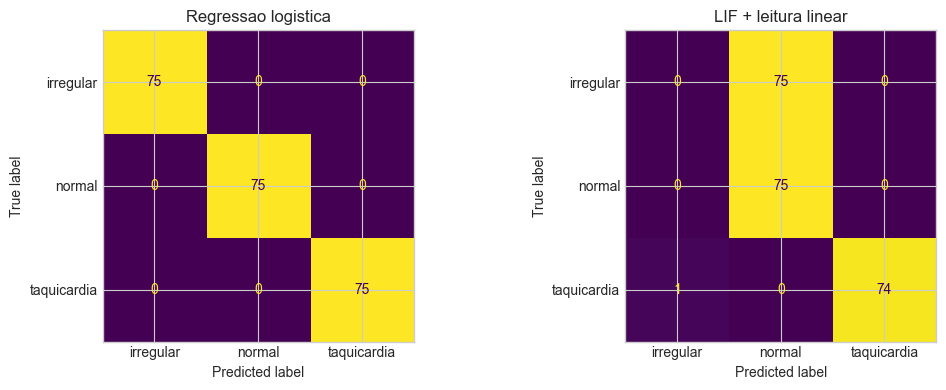

In [7]:
results = pd.DataFrame([
    {
        'modelo': 'Regressao logistica + atributos',
        'acuracia': accuracy_score(y_test, traditional_pred),
        'f1_macro': f1_score(y_test, traditional_pred, average='macro'),
        'numero_de_atributos': X_train_features.shape[1],
    },
    {
        'modelo': 'LIF + leitura linear',
        'acuracia': accuracy_score(y_test, lif_pred),
        'f1_macro': f1_score(y_test, lif_pred, average='macro'),
        'numero_de_atributos': X_lif_train.shape[1],
    },
])

display(results)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, traditional_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Regressao logistica')
ConfusionMatrixDisplay.from_predictions(y_test, lif_pred, ax=axes[1], colorbar=False)
axes[1].set_title('LIF + leitura linear')
plt.tight_layout()
plt.show()

## 5. Analise critica

- A regressao logistica e mais interpretavel, rapida e facil de justificar.
- O modelo LIF preserva a ordem temporal durante a simulacao e representa informacao por disparos.
- Nesta base sintetica, a engenharia de atributos favorece o modelo tradicional.
- O LIF simples depende fortemente de parametros definidos manualmente, como limiar, ganho e constante de tempo.
- Em dados reais de saude, seria essencial validar por paciente, analisar falso negativo e usar metricas clinicas como sensibilidade e especificidade.

Conclusao: a regressao logistica e uma linha de base forte e explicavel; o LIF e interessante para discutir processamento temporal e neuromorfico, mas precisa de calibracao e validacao rigorosa antes de uso pratico.